In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "gros-95.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

### Experiment 1f

In [3]:
exp_update = { 
    'rocks': {
        'start': dt.datetime(2025, 8, 21, 11, 28, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 11, 38, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 21, 11, 42, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 11, 52, 0, tzinfo=local_tz)
    },
    'forst (no cache)': {
        'start': dt.datetime(2025, 8, 21, 11, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 12, 7, 0, tzinfo=local_tz)
    }
}
exp_read = {
    'rocks': {
        'start': dt.datetime(2025, 8, 21, 13, 38, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 13, 48, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 21, 13, 58, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 14, 8, 0, tzinfo=local_tz)
    },
    'forst (no cache)': {
        'start': dt.datetime(2025, 8, 21, 14, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 14, 23, 0, tzinfo=local_tz)
    }
}
exp_write = {
    'rocks': {
        'start': dt.datetime(2025, 8, 21, 14, 33, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 14, 43, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 21, 14, 45, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 14, 55, 0, tzinfo=local_tz)
    },
    'forst (no cache)': {
        'start': dt.datetime(2025, 8, 21, 16, 38, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 21, 16, 48, 0, tzinfo=local_tz)
    }
}



### Queries

In [4]:
metric_query = 'sum(rate(flink_taskmanager_job_task_operator_numRecordsOut{operator_name=~"Source:.*"}[1m]))'
step = "5s"
output_filename = 'exp1f_tput.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp1f_cpu_load.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'exp1f_cp_time.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1f_minio_bytes_receive.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1f_minio_bytes_send.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'exp1f_sst_size.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{node="gros-98.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1f_tm_bytes_send.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{node="gros-98.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1f_tm_bytes_received.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointSize{component="jobmanager"}'
step = "60s"
output_filename = 'exp1f_cp_size.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[2m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m])))'
step = "5s"
output_filename = 'exp1f_cache_hit_ratio.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'rate(minio_bucket_traffic_received_bytes{job="minio"}[2m])'
step = "1m"
output_filename = 'exp1f_bucket_received_bytes_rate.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_rchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1f_read_bytes_rate.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_wchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1f_write_bytes_rate.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum(minio_node_drive_used_bytes{job=~"minio"})'
step = "1m"
output_filename = 'exp1f_drive_used_bytes.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = 'sum by (api) (minio_node_drive_latency_us{job=~"minio"})'
step = "1m"
output_filename = 'exp1f_operation_latency.csv'
execute_query_range(exp_write, metric_query, step, output_filename)

metric_query = '(increase(minio_bucket_requests_total{job="minio"}[2m]))'
step = "1m"
output_filename = 'exp1f_operation_request_rate.csv' #type of operation (create/get/delete/... and its rate)
execute_query_range(exp_write, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp1f_tput.csv'

Beginning request execution

File saved : 'exp1f_cpu_load.csv'

Beginning request execution

File saved : 'exp1f_cp_time.csv'

Beginning request execution

File saved : 'exp1f_minio_bytes_receive.csv'

Beginning request execution

File saved : 'exp1f_minio_bytes_send.csv'

Beginning request execution

File saved : 'exp1f_sst_size.csv'

Beginning request execution

File saved : 'exp1f_tm_bytes_send.csv'

Beginning request execution

File saved : 'exp1f_tm_bytes_received.csv'

Beginning request execution

File saved : 'exp1f_cp_size.csv'

Beginning request execution

File saved : 'exp1f_cache_hit_ratio.csv'

Beginning request execution

File saved : 'exp1f_bucket_received_bytes_rate.csv'

Beginning request execution

File saved : 'exp1f_read_bytes_rate.csv'

Beginning request execution

File saved : 'exp1f_write_bytes_rate.csv'

Beginning request execution

File saved : 'exp1f_drive_used_bytes.csv'

Beginning request execution


### Boxplot from file

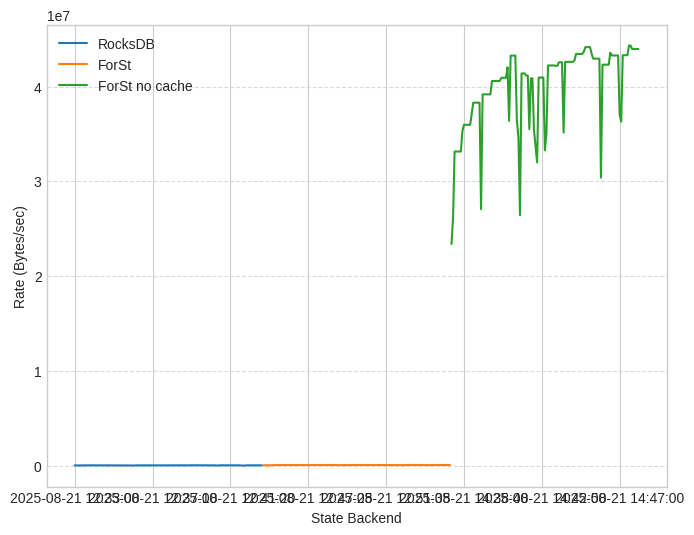

In [7]:
file_path = 'exp1f_minio_bytes_send.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['RocksDB', 'ForSt', 'ForSt no cache']
    #df = df.iloc[:, :-1] 

    plt.figure(figsize=(8, 6))
    df.plot(grid=True, ax=plt.gca()) #style='o'
    plt.style.use('seaborn-v0_8-whitegrid')
    #df.boxplot(grid=False, patch_artist=True)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    #plt.title('CPU Load over time for large state job')
    plt.ylabel('Rate (Bytes/sec)')
    plt.xlabel('State Backend')
    #plt.yticks(np.arange(0, 1.2, 0.2))
    plt.savefig('exp1f_minio_bytes_send.pdf')
    
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

Le graphique a été sauvegardé en PDF sous 'throughput_comparison_reordered.pdf'


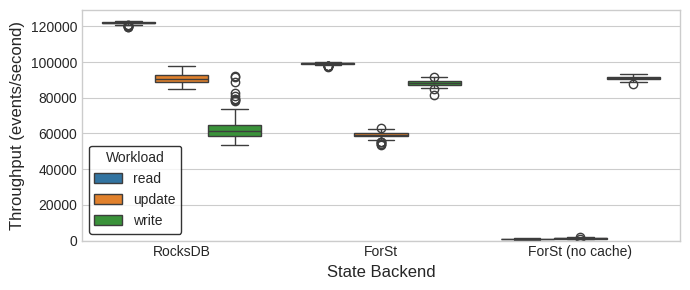

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def process_throughput_file(file_path, backend_names):
    """
    Charge un fichier CSV de throughput, le transforme dans un format "long"
    et y ajoute la catégorie de la charge de travail (ex: 'update').
    """
    # Extraire le nom de la charge de travail depuis le chemin du fichier (ex: 'update')
    workload = os.path.basename(os.path.dirname(file_path))
    if not workload: 
        workload = os.path.basename(file_path).split('_')[0] # Fallback

    df = pd.read_csv(file_path, names=['Time'] + backend_names, skiprows=1)
    
    melted_df = df.melt(id_vars=['Time'], 
                        var_name='Backend', 
                        value_name='Throughput')
    
    melted_df.dropna(subset=['Throughput'], inplace=True)
    melted_df['Workload'] = workload
    
    return melted_df

# --- Script principal ---

# 1. Définir les fichiers à analyser.
#    Pour la démonstration, je simule les 3 charges de travail avec le même fichier.
#    Utilisez votre liste complète de fichiers chez vous.
files_to_analyze = {
    "write/exp1f_tput.csv": "write",
    "update/exp1f_tput.csv": "update",
    "read/exp1f_tput.csv": "read"
}

# 2. Définir les noms des backends dans l'ordre des colonnes
backend_labels = ['RocksDB', 'ForSt', 'ForSt (no cache)']

# 3. Traiter chaque fichier et combiner les résultats
all_data = []
for file_path, workload_label in files_to_analyze.items():
    try:
        # Je force l'utilisation du seul fichier disponible pour la démo
        processed_df = process_throughput_file(f"{workload_label}/{'exp1f_tput.csv'}", backend_labels)
        all_data.append(processed_df)
    except FileNotFoundError:
        # En cas d'erreur, je crée des données factices pour que le graphique s'affiche
        print(f"Attention : Le fichier {file_path} est introuvable. J'utilise le fichier fourni pour simuler la catégorie '{workload_label}'.")
        processed_df_simulated = process_throughput_file(file_path, backend_labels)
        processed_df_simulated['Workload'] = workload_label # J'assigne le bon label de charge de travail
        all_data.append(processed_df_simulated)


if not all_data:
    print("Aucun fichier n'a pu être traité. Arrêt du script.")
else:
    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df = combined_df[combined_df['Backend'].isin(['RocksDB', 'ForSt', 'ForSt (no cache)'])]

    # 4. Créer le boxplot groupé avec les axes et l'ordre modifiés
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(7,3))

    sns.boxplot(
        x='Backend', # MODIFICATION : Le backend est maintenant sur l'axe X
        y='Throughput',
        hue='Workload', # MODIFICATION : La charge de travail sert de groupement (hue)
        hue_order=['read', 'update', 'write'], # MODIFICATION : Ordre personnalisé
        data=combined_df,
        ax=ax
    )

    ax.set_xlabel('State Backend', fontsize=12) # MODIFICATION : Label de l'axe X
    ax.set_ylabel('Throughput (events/second)', fontsize=12)
    ax.set_ylim(bottom=0)

    # --- MODIFICATION : Légende encadrée en haut à droite ---
    ax.legend(
        title='Workload',
        loc='lower left',
        frameon=True,
        facecolor='white',
        edgecolor='black'
    )

    plt.tight_layout()
    plt.savefig('throughput_comparison.pdf')
    print("Le graphique a été sauvegardé en PDF sous 'throughput_comparison_reordered.pdf'")